In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
import numpy as np

In [14]:
file_path = "epa-sea-level.csv"
df = pd.read_csv(file_path)
df.head

<bound method NDFrame.head of      Year  CSIRO Adjusted Sea Level  Lower Error Bound  Upper Error Bound  \
0    1880                  0.000000          -0.952756           0.952756   
1    1881                  0.220472          -0.732283           1.173228   
2    1882                 -0.440945          -1.346457           0.464567   
3    1883                 -0.232283          -1.129921           0.665354   
4    1884                  0.590551          -0.283465           1.464567   
..    ...                       ...                ...                ...   
129  2009                  8.586614           8.311024           8.862205   
130  2010                  8.901575           8.618110           9.185039   
131  2011                  8.964567           8.661417           9.267717   
132  2012                  9.326772           8.992126           9.661417   
133  2013                  8.980315           8.622047           9.338583   

     NOAA Adjusted Sea Level  
0             

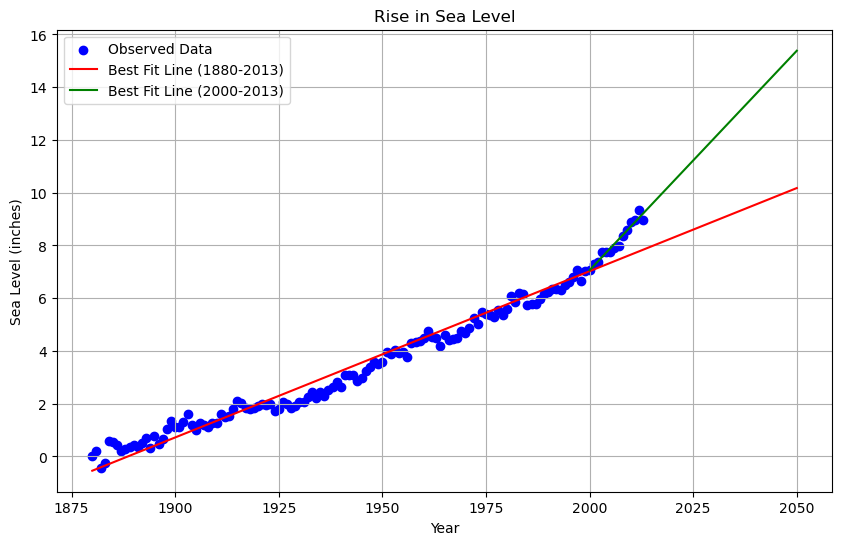

In [15]:
# Third cell - Create the visualization
plt.figure(figsize=(10, 6))

# Scatter plot of observed data
plt.scatter(df['Year'], df['CSIRO Adjusted Sea Level'], 
            color='blue', label='Observed Data')

# First line of best fit (all data)
res1 = linregress(df['Year'], df['CSIRO Adjusted Sea Level'])
years_extended = np.arange(1880, 2051)
plt.plot(years_extended, res1.intercept + res1.slope*years_extended, 
         'r', label='Best Fit Line (1880-2013)')

# Second line of best fit (2000 onwards)
recent_data = df[df['Year'] >= 2000]
res2 = linregress(recent_data['Year'], recent_data['CSIRO Adjusted Sea Level'])
years_recent = np.arange(2000, 2051)
plt.plot(years_recent, res2.intercept + res2.slope*years_recent, 
         'green', label='Best Fit Line (2000-2013)')

# Formatting
plt.xlabel('Year')
plt.ylabel('Sea Level (inches)')
plt.title('Rise in Sea Level')
plt.legend()
plt.grid(True)

# Save and show
plt.savefig('sea_level_rise.png')  # Will save in your current working directory
plt.show()

In [16]:
# Fourth cell - Print predictions
print(f"Predicted sea level rise in 2050 (all data): {res1.intercept + res1.slope*2050:.2f} inches")
print(f"Predicted sea level rise in 2050 (since 2000): {res2.intercept + res2.slope*2050:.2f} inches")

Predicted sea level rise in 2050 (all data): 10.18 inches
Predicted sea level rise in 2050 (since 2000): 15.38 inches
